# Anomaly Detection Pipeline

Multi-dimensional sensor data: **8 sensors × 10 heating steps × m GR values** per block.

**Pipeline:**
1. Calibration (Normal Air per substance)
2. Normalization
3. Sensor validity check
4. Feature extraction
5. Visualization — statistics (80 raw + 80 normalized plots per substance)
6. **t-SNE** (2D) for substance visualization — `pipeline_output/dim_reduction/dim_reduction_tsne.png`  
7. Anomaly scoring — IF+PCA, IF raw, dense AE + **confusion matrices** per model  
8. **Roadmap** — thesis plan; embedded t-SNE + confusion matrices; AE/CNN notes; checklist

In [ ]:
import sys
from pathlib import Path

# Add project folder to path
_here = Path.cwd()
if (_here / "data_utils.py").exists():
    sys.path.insert(0, str(_here))
else:
    _alt = _here / "Nw File Anomaly Detection"
    if (_alt / "data_utils.py").exists():
        sys.path.insert(0, str(_alt))

import json
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from data_utils import (
    BASE_DIR, SUBSTANCES, N_SENSORS, N_STEPS, STAT_NAMES, N_WARMUP, M_STEADY,
    TARGET_SAMPLES_PER_SUBSTANCE, TARGET_SAMPLES_AIR_NEW, WINDOW_STRIDE,
    load_folder_blocks, compute_baseline, compute_stats, apply_windowing,
    apply_windowing_multi, normalize_block, extract_features, get_valid_sensors,
    resolve_substance_folder, resolve_air_new_folder, resolve_combined_air_new_csv,
    load_combined_air_new_csv, AIR_NEW_COMBINED_CSV_CANDIDATES,
    load_substance_measurement_blocks,
)

SUBSTANCE_PREFIX = {"Acetone": "Acetone", "Redidlo": "Redidlo", "Softasept": "Softasept", "Savo": "Savo", "Vinegar": "Vinegar"}
print("BASE_DIR:", BASE_DIR)

BASE_DIR: C:\Users\yonat\OneDrive\Desktop\Nw File Anomaly Detection


## Step 1: Calibration (Normal Air per substance)

Normal Air under each substance folder is **calibration only** (baseline). The **normal class** for IF/AE is **`Air_New`** from the **`Air New`** folder (Step 4).

In [ ]:
calibration = {}
normal_blocks = {}

for sub in SUBSTANCES:
    folder = BASE_DIR / sub
    if not folder.exists():
        print(f"Skip {sub}: folder not found")
        continue
    # Try Normal_Air_* (consolidated) or Normal* (legacy)
    blocks, labels = load_folder_blocks(folder, "Normal_Air_*")
    if not blocks:
        blocks, labels = load_folder_blocks(folder, "Normal*")
    if not blocks:
        blocks, labels = load_folder_blocks(folder, "Nomal*")
    windowed, wl = [], []
    for b, lbl in zip(blocks, labels):
        for i, w in enumerate(apply_windowing_multi(b, stride=WINDOW_STRIDE)):
            windowed.append(w)
            wl.append(f"{lbl}_w{i}" if i > 0 else lbl)
    baseline = compute_baseline(windowed, apply_windowing_flag=False)
    calibration[sub] = baseline
    normal_blocks[sub] = (windowed, wl)
    print(f"{sub}: {len(blocks)} files -> {len(windowed)} Normal Air windows, baseline for {len(baseline)} (sensor,step) pairs")

Acetone: 22 files -> 346 Normal Air windows, baseline for 80 (sensor,step) pairs
Redidlo: 26 files -> 412 Normal Air windows, baseline for 80 (sensor,step) pairs
Softasept: 24 files -> 464 Normal Air windows, baseline for 80 (sensor,step) pairs
Savo: 24 files -> 430 Normal Air windows, baseline for 80 (sensor,step) pairs
Vinegar: 26 files -> 400 Normal Air windows, baseline for 80 (sensor,step) pairs


## Step 2 & 3: Normalization + Sensor validity

Normalize raw GR using baseline. Exclude invalid sensors per block.

In [ ]:
def load_substance_data(sub: str):
    """Vapour blocks only (sliding windows). Normal_Air stays calibration-only."""
    folder = resolve_substance_folder(BASE_DIR, sub)
    if folder is None:
        return [], []
    sub_blocks, sub_labels = load_substance_measurement_blocks(folder, sub)
    sub_windowed, sub_windowed_labels = [], []
    for b, lbl in zip(sub_blocks, sub_labels):
        for i, w in enumerate(apply_windowing_multi(b, stride=WINDOW_STRIDE)):
            sub_windowed.append(w)
            sub_windowed_labels.append(f"{lbl}_w{i}" if i > 0 else lbl)
    return sub_windowed, sub_windowed_labels


def process_blocks(blocks, labels, baseline, substance_label, return_blockwise=False):
    """Normalize blocks, apply validity check, return raw/norm data."""
    raw_by_sensor_step = defaultdict(list)
    norm_by_sensor_step = defaultdict(list)
    valid_blocks = []
    raw_blocks = []
    norm_blocks = []
    for blk, lbl in zip(blocks, labels):
        valid_s = get_valid_sensors(blk)
        if len(valid_s) < 4:
            continue
        norm_blk = normalize_block(blk, baseline)
        raw_blocks.append(blk)
        norm_blocks.append(norm_blk)
        valid_blocks.append({
            "label": lbl,
            "valid_sensors": valid_s,
        })
        for (s, st), vals in blk.items():
            if s in valid_s and vals:
                raw_by_sensor_step[(s, st)].extend(vals)
        for (s, st), arr in norm_blk.items():
            if s in valid_s and len(arr) > 0:
                norm_by_sensor_step[(s, st)].extend(arr.tolist())
    if return_blockwise:
        return raw_blocks, norm_blocks, valid_blocks
    return raw_by_sensor_step, norm_by_sensor_step, valid_blocks

In [ ]:
# process_blocks is defined in the cell above

## Step 4: Feature extraction

In [ ]:
air_folder = resolve_air_new_folder(BASE_DIR)
air_csv = resolve_combined_air_new_csv(BASE_DIR)
if air_folder is None or air_csv is None:
    raise FileNotFoundError(
        "Put folder 'Air New' under BASE_DIR with one combined CSV (name contains 'combined' or Air_New_combined.csv)."
    )
air_blocks, air_lbls = load_combined_air_new_csv(air_csv)
air_windowed, air_wlbls = [], []
for b, lbl in zip(air_blocks, air_lbls):
    for i, w in enumerate(apply_windowing_multi(b, stride=WINDOW_STRIDE)):
        air_windowed.append(w)
        air_wlbls.append(f"{lbl}_w{i}" if i > 0 else lbl)
ref_sub = next(s for s in SUBSTANCES if s in calibration)
baseline_air = calibration[ref_sub]
print(f"Air New: {len(air_windowed)} windows from {air_csv.name}; norm baseline = {ref_sub}")

all_features_raw = []
all_features_calib = []
all_labels = []
rng = np.random.default_rng(42)

raw_r, norm_r, vb = process_blocks(air_windowed, air_wlbls, baseline_air, "Air_New", return_blockwise=True)
air_ix = list(range(len(vb)))
if len(air_ix) > TARGET_SAMPLES_AIR_NEW:
    air_ix = list(rng.choice(len(vb), TARGET_SAMPLES_AIR_NEW, replace=False))
for i in air_ix:
    sample = vb[i]
    valid_s = sample["valid_sensors"]
    all_features_raw.append(extract_features(raw_r[i], baseline_air, valid_s))
    all_features_calib.append(extract_features(norm_r[i], baseline_air, valid_s))
    all_labels.append("Air_New")

for sub in SUBSTANCES:
    if sub not in calibration:
        continue
    sub_blks, sub_lbls = load_substance_data(sub)
    baseline = calibration[sub]
    if not sub_blks:
        continue
    labels = sub_lbls if len(sub_lbls) == len(sub_blks) else [f"b{i}" for i in range(len(sub_blks))]
    raw_r, norm_r, valid_blocks = process_blocks(sub_blks, labels, baseline, sub, return_blockwise=True)
    indices = list(range(len(valid_blocks)))
    if len(indices) > TARGET_SAMPLES_PER_SUBSTANCE:
        indices = list(rng.choice(len(valid_blocks), TARGET_SAMPLES_PER_SUBSTANCE, replace=False))
    for i in indices:
        sample = valid_blocks[i]
        raw_blk = raw_r[i]
        calib_blk = norm_r[i]
        valid_s = sample["valid_sensors"]
        all_features_raw.append(extract_features(raw_blk, baseline, valid_s))
        all_features_calib.append(extract_features(calib_blk, baseline, valid_s))
        all_labels.append(sub)

X_raw = np.vstack(all_features_raw)
X_calib = np.vstack(all_features_calib)
X = X_calib  # default alias for downstream cells
y = np.array(all_labels)
print(f"X_raw: {X_raw.shape}, X_calib: {X_calib.shape}, labels: {len(np.unique(y))} classes")
for lab in np.unique(y):
    print(f"  {lab}: {(y == lab).sum()} samples")

Air New: 400 windows from Air_New_combined.csv; norm baseline = Acetone
X_raw: (1900, 800), X_calib: (1900, 800), labels: 6 classes
  Acetone: 300 samples
  Air_New: 400 samples
  Redidlo: 300 samples
  Savo: 300 samples
  Softasept: 300 samples
  Vinegar: 300 samples


## Step 5: Visualization — 80 plots raw + 80 normalized per substance

80 = 8 sensors × 10 HS. Each subplot shows distribution of values.

In [ ]:
OUTPUT_DIR = BASE_DIR / "pipeline_output"
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / "stats_plots").mkdir(exist_ok=True)

def plot_80_grid(data_by_sensor_step, title, filepath, stat_key="median"):
    """80 subplots: 8 sensors × 10 HS. Show distribution (e.g. median of values) per (sensor, step)."""
    fig, axes = plt.subplots(8, 10, figsize=(18, 12))
    for s in range(N_SENSORS):
        for st in range(N_STEPS):
            ax = axes[s, st]
            vals = data_by_sensor_step.get((s, st), [])
            if vals:
                arr = np.array(vals)
                stats = compute_stats(arr)
                v = stats.get(stat_key, 0)
                if np.isnan(v) or np.isinf(v):
                    v = 0
                ax.bar([stat_key], [float(v)], color="steelblue", edgecolor="black")
            ax.set_xticks([])
            ax.set_title(f"S{s} HS{st}", fontsize=7)
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(filepath, dpi=100, bbox_inches="tight")
    plt.close()


for sub in SUBSTANCES:
    if sub not in calibration:
        continue
    sub_blks, sub_lbls = load_substance_data(sub)
    baseline = calibration[sub]
    raw_r, norm_r, _ = process_blocks(sub_blks, [""] * len(sub_blks), baseline, sub)
    plot_80_grid(raw_r, f"{sub} — Raw GR (median)", OUTPUT_DIR / f"stats_plots/{sub}_raw_median.png")
    plot_80_grid(norm_r, f"{sub} — Normalized GR (median)", OUTPUT_DIR / f"stats_plots/{sub}_normalized_median.png")
    print(f"Saved plots for {sub}")

Saved plots for Acetone
Saved plots for Redidlo
Saved plots for Softasept
Saved plots for Savo
Saved plots for Vinegar


### Step 5 (alt): 80 plots as histogram/distribution per (sensor, HS)

In [ ]:
def plot_80_histograms(data_by_sensor_step, title, filepath, bins=30):
    fig, axes = plt.subplots(8, 10, figsize=(20, 14))
    for s in range(N_SENSORS):
        for st in range(N_STEPS):
            ax = axes[s, st]
            vals = data_by_sensor_step.get((s, st), [])
            if vals:
                ax.hist(vals, bins=bins, color="steelblue", edgecolor="white", alpha=0.8)
            ax.set_title(f"S{s} HS{st}", fontsize=7)
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(filepath, dpi=100, bbox_inches="tight")
    plt.close()


for sub in SUBSTANCES:
    if sub not in calibration:
        continue
    sub_blks, sub_lbls = load_substance_data(sub)
    baseline = calibration[sub]
    raw_r, norm_r, _ = process_blocks(sub_blks, [""] * len(sub_blks), baseline, sub)
    plot_80_histograms(raw_r, f"{sub} — Raw GR distribution", OUTPUT_DIR / f"stats_plots/{sub}_raw_hist.png")
    plot_80_histograms(norm_r, f"{sub} — Normalized GR distribution", OUTPUT_DIR / f"stats_plots/{sub}_norm_hist.png")
    print(f"Saved histograms for {sub}")

Saved histograms for Acetone
Saved histograms for Redidlo
Saved histograms for Softasept
Saved histograms for Savo
Saved histograms for Vinegar


## Step 6: t-SNE (2D embedding)

Same as the paper: **only t-SNE** is used for exploratory 2D visualization of vapour classes (Air_New excluded). Step 11 still uses **PCA** internally for Isolation Forest — that is separate from this figure.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Switch between raw and normalized features for dim reduction
use_calibrated = True  # Set to False to use raw features (not normalized by baseline)
X_selected = X_calib if use_calibrated else X_raw

X_clean = np.nan_to_num(X_selected, nan=0.0, posinf=0.0, neginf=0.0)
na_fit_mask = np.array([str(lab) == "Air_New" for lab in y], dtype=bool)
if na_fit_mask.sum() >= 2:
    _sc = StandardScaler()
    _sc.fit(X_clean[na_fit_mask])
    X_scaled = _sc.transform(X_clean)
    print(f"StandardScaler fit on Air_New only (n={int(na_fit_mask.sum())}); vapours transformed without their stats.")
else:
    X_scaled = StandardScaler().fit_transform(X_clean)
    print("StandardScaler fit on all rows (fallback: too few Air_New).")

sub_mask = np.array([str(lab) in SUBSTANCES for lab in y], dtype=bool)
X_sub = X_scaled[sub_mask]
y_sub = y[sub_mask]
print(f"t-SNE input: {len(X_sub)} substance samples (Air_New excluded)")

perplexity = min(30, max(5, len(X_sub) - 1))
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
X_tsne = tsne.fit_transform(X_sub)

StandardScaler fit on Air_New only (n=400); vapours transformed without their stats.
t-SNE input: 1500 substance samples (Air_New excluded)


In [ ]:
def plot_embedding_2d(emb, labels, title, filepath, figsize=(7, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    for lab in np.unique(labels):
        m = labels == lab
        ax.scatter(emb[m, 0], emb[m, 1], label=lab, alpha=0.65, s=36)
    ax.set_title(title)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.legend(loc="best", fontsize=7, ncol=2, framealpha=0.9)
    plt.tight_layout()
    plt.savefig(filepath, dpi=120, bbox_inches="tight")
    plt.show()


(OUTPUT_DIR / "dim_reduction").mkdir(exist_ok=True)
plot_embedding_2d(
    X_tsne, y_sub, "Step 6 — t-SNE (2D, substances only)", OUTPUT_DIR / "dim_reduction/dim_reduction_tsne.png"
)
print("Saved:", OUTPUT_DIR / "dim_reduction/dim_reduction_tsne.png")

Saved: C:\Users\yonat\OneDrive\Desktop\Nw File Anomaly Detection\pipeline_output\dim_reduction\dim_reduction_tsne.png


## Step 11: Anomaly scoring & confusion matrices

**Ground truth:** `Air_New` (folder **Air New**) = normal (0); vapours = anomaly (1). Per-substance **Normal_Air** is calibration-only.

**Feature scaling (Step 6):** `StandardScaler` fit on **`Air_New`** rows only.

**Air New:** **one combined CSV** in folder `Air New` (filename contains `combined` or `Air_New_combined.csv`); sliding windows, cap **`TARGET_SAMPLES_AIR_NEW`**. Normal_Air in substance folders = calibration only.

**3-way Normal Air:** **train** (fit PCA / IF / AE), **cal** (thresholds only), **test** (in confusion matrices with all vapours). Train and cal normals are **excluded** from the CM.

**IF:** `decision_function` threshold from cal Normal (~5% FPR target).

**Dense AE:** 800-D recon score;

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

TARGET_FPR_CAL_NORMAL = 0.05
TARGET_FPR_CAL_NORMAL_AE = 0.12

y_str = np.asarray(y, dtype=str)
y_bin = np.array([0 if s == "Air_New" else 1 for s in y_str])
normal_mask = y_bin == 0
X_all = np.asarray(X_scaled, dtype=float)
X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

normal_idx = np.flatnonzero(normal_mask)
if len(normal_idx) < 15:
    raise ValueError("Need >=15 Air_New rows for train/cal/test. Run Step 4-6 first.")

rng = np.random.RandomState(42)
rng.shuffle(normal_idx)
n_n = len(normal_idx)
n_tr = max(1, int(round(0.55 * n_n)))
n_ca = max(5, int(round(0.25 * n_n)))
if n_tr + n_ca >= n_n - 2:
    n_ca = max(5, n_n // 5)
    n_tr = max(1, n_n - n_ca - max(3, n_n // 5))
normal_train_idx = normal_idx[:n_tr]
normal_cal_idx = normal_idx[n_tr : n_tr + n_ca]
normal_test_idx = normal_idx[n_tr + n_ca :]
if len(normal_test_idx) < 3:
    n_ca = max(5, n_n // 5)
    n_tr = max(1, n_n - n_ca - max(3, n_n // 5))
    normal_train_idx = normal_idx[:n_tr]
    normal_cal_idx = normal_idx[n_tr : n_tr + n_ca]
    normal_test_idx = normal_idx[n_tr + n_ca :]

X_n_tr = X_all[normal_train_idx]
X_n_cal = X_all[normal_cal_idx]

n_comp = min(60, X_n_tr.shape[1], max(X_n_tr.shape[0] - 1, 1))
pca_if = PCA(n_components=n_comp, random_state=42)
pca_if.fit(X_n_tr)
Z_all = pca_if.transform(X_all)
Z_n_tr = pca_if.transform(X_n_tr)
Z_n_cal = pca_if.transform(X_n_cal)

print(
    f"(1) PCA for IF: {X_all.shape[1]} -> {n_comp} (Normal train only), var={pca_if.explained_variance_ratio_.sum():.2%}"
)
print(
    f"    Normal 3-way: train={len(normal_train_idx)}, cal={len(normal_cal_idx)}, test={len(normal_test_idx)} (CM) | IF target cal FPR ~{TARGET_FPR_CAL_NORMAL:.0%}"
)

if_pca = IsolationForest(
    n_estimators=300, max_samples=min(256, len(Z_n_tr)), contamination=0.02, random_state=42, n_jobs=-1
)
if_pca.fit(Z_n_tr)
s_cal_pca = if_pca.decision_function(Z_n_cal)
thr_pca = float(np.percentile(s_cal_pca, 100 * TARGET_FPR_CAL_NORMAL))
scores_if_pca = if_pca.decision_function(Z_all)
pred_if_pca = (scores_if_pca < thr_pca).astype(int)
print(f"    IF+PCA: thr={thr_pca:.5f}, cal-Normal FPR={(s_cal_pca < thr_pca).mean():.2%}")

if_raw = IsolationForest(
    n_estimators=300, max_samples=min(256, len(X_n_tr)), contamination=0.02, random_state=42, n_jobs=-1
)
if_raw.fit(X_n_tr)
s_cal_raw = if_raw.decision_function(X_n_cal)
thr_raw = float(np.percentile(s_cal_raw, 100 * TARGET_FPR_CAL_NORMAL))
scores_if_raw = if_raw.decision_function(X_all)
pred_if_raw = (scores_if_raw < thr_raw).astype(int)
print(f"(2) IF raw: thr={thr_raw:.5f}, cal-Normal FPR={(s_cal_raw < thr_raw).mean():.2%}")

pc_std = Z_n_tr.std(axis=0)
noise_floor = float(np.percentile(pc_std, 25)) * 0.5 + 1e-8
pc_scale = np.maximum(pc_std, noise_floor)
rng_ae = np.random.RandomState(43)
noise_level = 0.5
Z_tr_noisy = Z_n_tr + rng_ae.standard_normal(Z_n_tr.shape) * (noise_level * pc_scale)

mlp_ae = MLPRegressor(
    hidden_layer_sizes=(24, 8, 24),
    activation="relu",
    solver="lbfgs",
    alpha=1e-2,
    max_iter=10000,
    random_state=42,
    tol=1e-5,
)
mlp_ae.fit(Z_tr_noisy, Z_n_tr)


def _ae_score(z_mat, x_mat, model):
    z_hat = model.predict(z_mat)
    x_hat = pca_if.inverse_transform(z_hat)
    e2 = (x_mat - x_hat) ** 2
    return np.mean(e2, axis=1) + 1.5 * np.percentile(e2, 95, axis=1)


mse_cal_ae = _ae_score(Z_n_cal, X_n_cal, mlp_ae)
mse_ae = _ae_score(Z_all, X_all, mlp_ae)
n_cal_ae = len(mse_cal_ae)
k_fpr = max(1, int(np.ceil(TARGET_FPR_CAL_NORMAL_AE * n_cal_ae)))
thr_ae = float(np.partition(np.asarray(mse_cal_ae, dtype=float), n_cal_ae - k_fpr)[n_cal_ae - k_fpr])
pred_ae = (mse_ae >= thr_ae).astype(int)
m_tr = _ae_score(Z_n_tr, X_n_tr, mlp_ae)
m_ca = mse_cal_ae
m_vap = mse_ae[y_bin == 1]
cal_fpr_ae = (mse_cal_ae >= thr_ae).mean()
print(
    f"(3) Dense DAE (800-D recon): thr={thr_ae:.6f}, cal-N flag rate={cal_fpr_ae:.2%} (~{k_fpr}/{n_cal_ae}) | "
    f"mean train-N={m_tr.mean():.4f}, cal-N={m_ca.mean():.4f}, vapour={m_vap.mean():.4f}"
)
vap_mask = y_bin == 1
n_vap = int(vap_mask.sum())
n_vap_hit = int((pred_ae[vap_mask] == 1).sum())
print(
    f"    AE vapour detection: {n_vap_hit}/{n_vap} blocks flagged ({100 * n_vap_hit / max(n_vap, 1):.1f}%)"
)

print("\nPer-label predicted anomaly rate (IF+PCA):")
for lab in np.unique(y):
    m = y == lab
    r = 100 * (pred_if_pca[m] == 1).sum() / max(m.sum(), 1)
    print(f"  {lab}: {m.sum()} samples, {r:.1f}% predicted anomaly")

n_all = len(y_bin)
eval_mask = (y_bin == 1) | np.isin(np.arange(n_all, dtype=int), normal_test_idx)

pd.DataFrame(
    {
        "label": y,
        "y_true_binary": y_bin,
        "pred_if_pca": pred_if_pca,
        "pred_if_raw": pred_if_raw,
        "pred_dense_ae": pred_ae,
        "score_if_pca": scores_if_pca,
        "score_if_raw": scores_if_raw,
        "mse_ae": mse_ae,
        "thr_if_pca": np.full(len(y), thr_pca),
        "thr_if_raw": np.full(len(y), thr_raw),
        "thr_ae_mse": np.full(len(y), thr_ae),
        "in_cm_eval_set": eval_mask.astype(int),
    }
).to_csv(OUTPUT_DIR / "anomaly_scores.csv", index=False)

(OUTPUT_DIR / "confusion_matrices").mkdir(exist_ok=True)

cm_note = (
    f"unbiased CM: test Normal (n={len(normal_test_idx)}) + all vapour; train/cal Normal excluded"
)
y_ev = y_bin[eval_mask]


def plot_confusion(y_true, y_pred, title, filename):
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"]).plot(
        ax=axes[0], cmap="Blues", colorbar=False, values_format="d"
    )
    axes[0].set_title("Counts")
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=[0, 1],
        display_labels=["Normal", "Anomaly"],
        normalize="true",
        values_format=".2f",
        cmap="Blues",
        colorbar=False,
        ax=axes[1],
    )
    axes[1].set_title("By true class (recall)")
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=[0, 1],
        display_labels=["Normal", "Anomaly"],
        normalize="pred",
        values_format=".2f",
        cmap="Blues",
        colorbar=False,
        ax=axes[2],
    )
    axes[2].set_title("By predicted class (precision)")
    fig.suptitle(title, fontsize=10.5, y=1.02)
    plt.tight_layout()
    out = OUTPUT_DIR / "confusion_matrices" / filename
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(out)
    print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"], digits=3))


plot_confusion(
    y_ev,
    pred_if_pca[eval_mask],
    f"IF + PCA | cal ~{TARGET_FPR_CAL_NORMAL:.0%} FPR | {cm_note}",
    "confusion_if_pca.png",
)
plot_confusion(
    y_ev,
    pred_if_raw[eval_mask],
    f"IF raw | cal ~{TARGET_FPR_CAL_NORMAL:.0%} FPR | {cm_note}",
    "confusion_if_raw.png",
)
plot_confusion(
    y_ev,
    pred_ae[eval_mask],
    f"Dense DAE | cal k-of-n ~{TARGET_FPR_CAL_NORMAL_AE:.0%} | {cm_note}",
    "confusion_dense_ae.png",
)
print(f"CM eval subset size: {eval_mask.sum()}")

fig, ax = plt.subplots(figsize=(10, 5))
for lab in np.unique(y):
    mask = y == lab
    ax.hist(scores_if_pca[mask], bins=20, alpha=0.5, label=lab, density=True)
ax.axvline(thr_pca, color="black", linestyle="--", label=f"threshold ({thr_pca:.4f})")
ax.set_xlabel("IF+PCA decision_function (higher = more normal)")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Step 11: IF+PCA score by substance")
plt.tight_layout()
p_hist = OUTPUT_DIR / "anomaly_scores.png"
plt.savefig(p_hist, dpi=120, bbox_inches="tight")
plt.show()
print(p_hist)

(1) PCA for IF: 800 -> 60 (Normal train only), var=99.93%
    Normal 3-way: train=220, cal=100, test=80 (CM) | IF target cal FPR ~5%
    IF+PCA: thr=-0.06908, cal-Normal FPR=5.00%
(2) IF raw: thr=0.03688, cal-Normal FPR=5.00%
(3) Dense DAE (800-D recon): thr=2.240428, cal-N flag rate=12.00% (~12/100) | mean train-N=0.9468, cal-N=1.5821, vapour=11.0217
    AE vapour detection: 1114/1500 blocks flagged (74.3%)

Per-label predicted anomaly rate (IF+PCA):
  Acetone: 300 samples, 24.0% predicted anomaly
  Air_New: 400 samples, 2.0% predicted anomaly
  Redidlo: 300 samples, 2.7% predicted anomaly
  Savo: 300 samples, 1.7% predicted anomaly
  Softasept: 300 samples, 100.0% predicted anomaly
  Vinegar: 300 samples, 0.0% predicted anomaly
C:\Users\yonat\OneDrive\Desktop\Nw File Anomaly Detection\pipeline_output\confusion_matrices\confusion_if_pca.png
              precision    recall  f1-score   support

      Normal      0.065     0.963     0.121        80
     Anomaly      0.992     0.257    

## Roadmap - based on the feedback (thesis & experiments)

**Status:** Windowing and 800-D statistical features are in place. Next work ties sample size, feature dimension, and model complexity to avoid overfitting.

### IsolationForest improve after 800 → 60 dimensions (PCA)?

- **Curse of dimensionality:** In high-D space, distances become less meaningful; “normal” points look scattered and the isolation process is noisy.
- **Sample size vs. features:** With a limited number of Normal-Air windows, 800 free dimensions is far larger than justified; the model can fit noise.
- **Redundancy:** Many of the 800 stats are correlated; PCA concentrates variance into fewer orthogonal directions so IF sees a stabler geometry.

---

### Deliverables (next steps)

| # | Task | Output for thesis |
|---|------|-------------------|
| 1 | Study **training set size ↔ input dimension ↔ model complexity** | New **chapter** + **tables** (see below) |
| 2 | Propose a **small dense autoencoder** (respect ~**1k–2k parameters**; see next cells) | Architecture diagram + parameter count |
| 3 | **Automatic features** from windowed series (e.g. **1D CNN** on GR windows) | Method 2 pipeline + ablation vs manual 800-D |
| 4 | Tune **Isolation Forest** and **AE** with the above in mind | Hyperparameter table + justification; **Step 11** saves per-model confusion matrices in `pipeline_output/confusion_matrices/` |




### Roadmap — dimensionality reduction (t-SNE)

Step 6 saves **one** figure: `dim_reduction_tsne.png` (vapour classes only; same scope as the paper).

## t-SNE (2D, substances only)

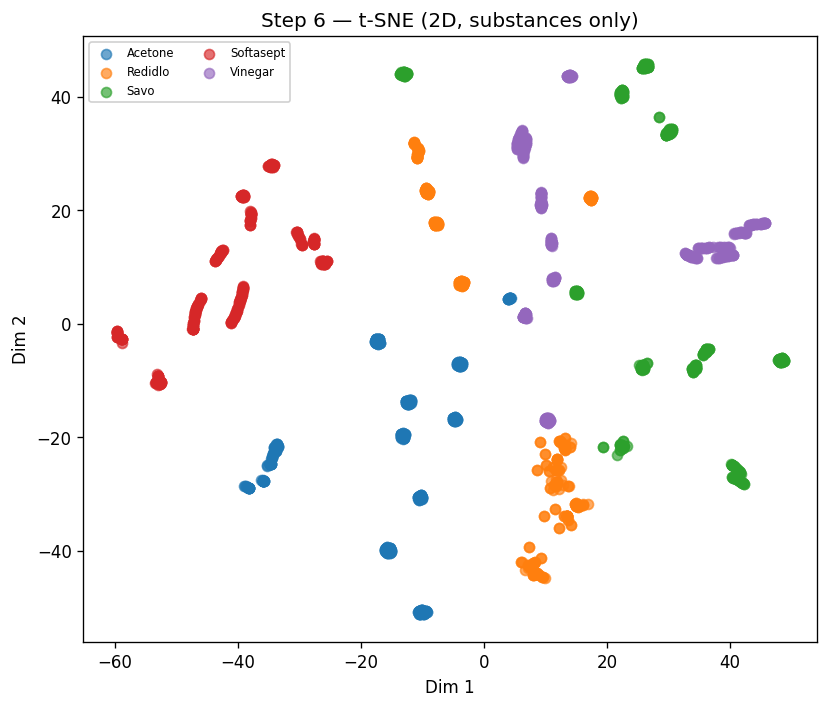

In [ ]:
from IPython.display import display, Image, Markdown

_ro = BASE_DIR / "pipeline_output" / "dim_reduction"
display(Markdown("## t-SNE (2D, substances only)"))
p = _ro / "dim_reduction_tsne.png"
display(Image(filename=str(p), width=760) if p.is_file() else Markdown(f"*Run **Step 6** — missing `{p}`*"))


### Roadmap — confusion matrices (todo ML algorithms)

**Models:** (1) Isolation Forest + PCA, (2) Isolation Forest on raw features, (3) dense autoencoder (reconstruction MSE). **Truth:** Normal = `Normal_Air*`, Anomaly = vapour substance labels. Saved by Step 11.

## 1. Isolation Forest + PCA

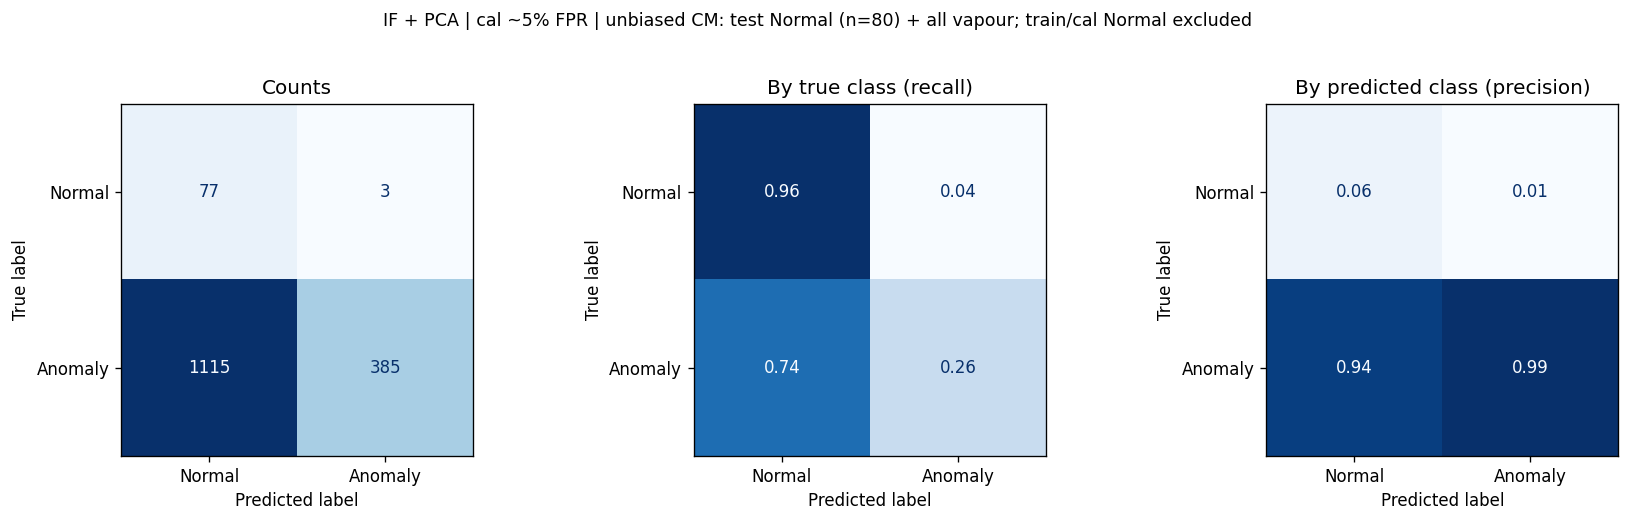

## 2. Isolation Forest — raw scaled features

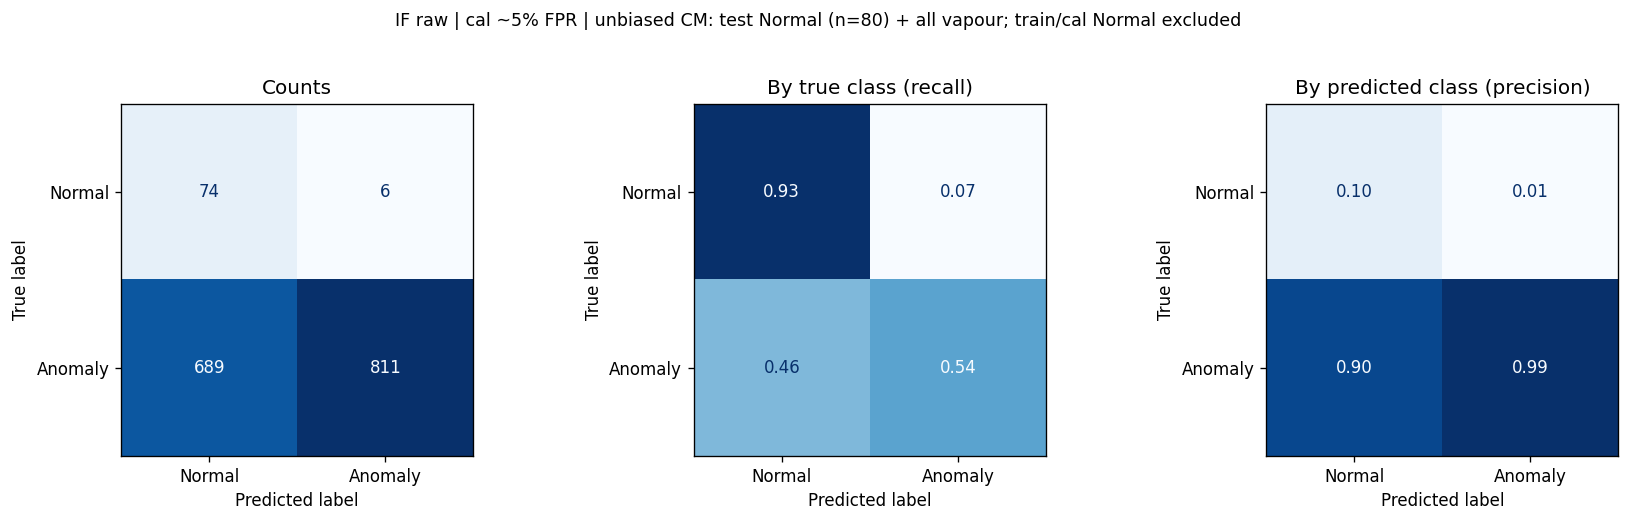

## 3. Dense autoencoder (MSE threshold)

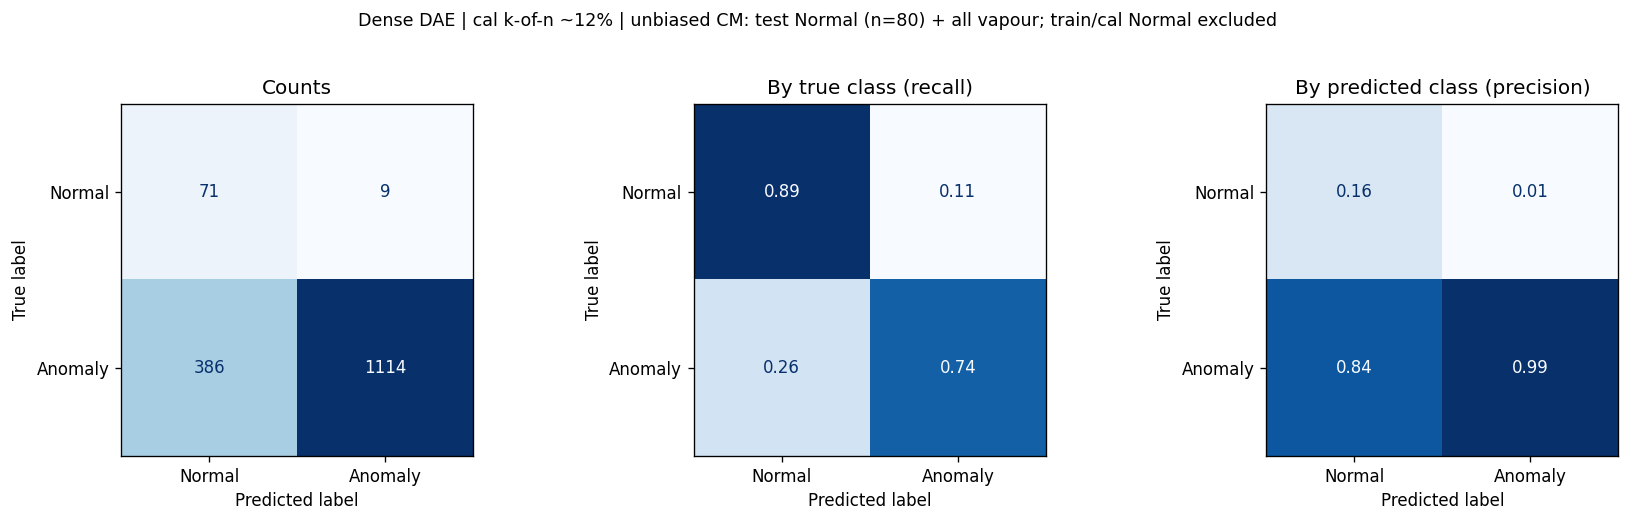

In [ ]:
from IPython.display import display, Image, Markdown

_cm = BASE_DIR / "pipeline_output" / "confusion_matrices"
display(Markdown("## 1. Isolation Forest + PCA"))
p = _cm / "confusion_if_pca.png"
display(Image(filename=str(p), width=520) if p.is_file() else Markdown(f"*Run **Step 11** — missing `{p}`*"))
display(Markdown("## 2. Isolation Forest — raw scaled features"))
p = _cm / "confusion_if_raw.png"
display(Image(filename=str(p), width=520) if p.is_file() else Markdown(f"*Run **Step 11** — missing `{p}`*"))
display(Markdown("## 3. Dense autoencoder (MSE threshold)"))
p = _cm / "confusion_dense_ae.png"
display(Image(filename=str(p), width=520) if p.is_file() else Markdown(f"*Run **Step 11** — missing `{p}`*"))


In [ ]:
# Roadmap — sample size vs feature dimension (thesis numbers; run after Step 4)
from sklearn.decomposition import PCA


def _normal_air_mask(y_arr):
    y_arr = np.asarray(y_arr, dtype=str)
    return np.array([s.startswith("Normal_Air") for s in y_arr])


def roadmap_complexity_report(X_feat, y_labels, n_pca_target=60, random_state=42):
    """Print N_train, D_raw, fitted PCA dim, explained variance, N/D ratios for thesis tables."""
    Xc = np.asarray(X_feat, dtype=float)
    Xc = np.nan_to_num(Xc, nan=0.0, posinf=0.0, neginf=0.0)
    y_arr = np.asarray(y_labels)
    N, D = Xc.shape
    nm = _normal_air_mask(y_arr)
    N_train = int(nm.sum())
    X_train = Xc[nm] if N_train > 0 else Xc
    n_comp = min(n_pca_target, D, max(X_train.shape[0] - 1, 1))
    pca = PCA(n_components=n_comp, random_state=random_state)
    pca.fit(X_train)
    var = float(pca.explained_variance_ratio_.sum())
    print("=== Thesis metrics (curse of dimensionality / N vs D) ===")
    print(f"  N (all samples)      : {N}")
    print(f"  N_train (Normal_Air*): {N_train}")
    print(f"  D_raw                : {D}")
    print(f"  D_PCA (fitted)       : {n_comp}  |  cumulative explained variance: {var:.2%}")
    print(f"  N_train / D_raw      : {N_train / max(D, 1):.4f}")
    print(f"  N_train / D_PCA      : {N_train / max(n_comp, 1):.4f}")
    return {"N": N, "N_train": N_train, "D_raw": D, "D_pca": n_comp, "explained_var": var}


try:
    _roadmap_stats = roadmap_complexity_report(X, y, n_pca_target=60)
except NameError:
    print("Run Step 4 first (defines X, y), then re-run this cell.")


=== Thesis metrics (curse of dimensionality / N vs D) ===
  N (all samples)      : 1900
  N_train (Normal_Air*): 0
  D_raw                : 800
  D_PCA (fitted)       : 60  |  cumulative explained variance: 99.91%
  N_train / D_raw      : 0.0000
  N_train / D_PCA      : 0.0000


### Thesis — suggested chapter: *Sample size, dimensionality, and model complexity*

**Fill these tables with your actual numbers after experiments.**

| Symbol | Meaning | Your value (example) |
|--------|---------|----------------------|
| \(N_{\text{train}}\) | Number of Normal-Air training windows | |
| \(D_{\text{raw}}\) | Raw feature dim (stats) | 800 |
| \(D_{\text{PCA}}\) | Dim after PCA / reduction | 60 |
| \(P_{\text{model}}\) | Trainable parameters (IF: 0; AE: count) | |
| Ratio \(N/D\) | Rule-of-thumb: avoid \(D \gg N\) | |

| Model | Input dim | Key hyperparameters | \(P\) (params) | Notes |
|-------|-----------|---------------------|----------------|-------|
| IsolationForest | 60 after PCA | `n_estimators`, `max_samples`, `contamination` | 0 | Tune on validation Normal Air |
| Dense AE | 60 after PCA | hidden sizes, bottleneck, epochs, LR | see next cell | Reconstruction MSE = score |
| 1D CNN encoder | length × channels | kernel sizes, filters, pool | TBD | Then PCA on embedding |

**Text to argue in thesis:** when \(D\) is large relative to \(N\), distance-based and tree-based methods degrade; PCA (or AE) acts as regularization. Cite *curse of dimensionality* and *double descent* only if you use them precisely.

In [ ]:
# Optional: build a small DataFrame row for the thesis table (after previous cell)
try:
    row = {
        "N_train": _roadmap_stats["N_train"],
        "D_raw": _roadmap_stats["D_raw"],
        "D_PCA": _roadmap_stats["D_pca"],
        "P_IForest": 0,
        "N_over_D_raw": _roadmap_stats["N_train"] / max(_roadmap_stats["D_raw"], 1),
    }
    print(pd.DataFrame([row]).to_string(index=False))
except NameError:
    print("Run the cell above first (defines _roadmap_stats).")


 N_train  D_raw  D_PCA  P_IForest  N_over_D_raw
       0    800     60          0           0.0


### Dense autoencoder proposal (~1k–2k parameters)

Working on **PCA-reduced** vectors (e.g. **60** dims) keeps the linear layer counts small; 800→… directly would need far more than 2k weights.

**Architecture (symmetric):** `60 → 12 → 4 → 12 → 60` (ReLU between linear layers; linear output for reconstruction).

| Layer | Shape | Weights | Bias | Subtotal |
|-------|-------|---------|------|----------|
| Encoder 1 | (60, 12) | 720 | 12 | 732 |
| Encoder 2 | (12, 4) | 48 | 4 | 52 |
| Decoder 1 | (4, 12) | 48 | 12 | 60 |
| Decoder 2 | (12, 60) | 720 | 60 | 780 |
| **Total** | | | | **≈ 1 624** |

Train only on **Normal Air** windows; anomaly score = **MSE** between input and reconstruction. Validate contamination / threshold on held-out Normal Air.

*If advisor allows slightly more parameters, widen 12→16 or bottleneck 4→8 and re-count before training.*

In [ ]:
# Dense AE: exact linear parameter count + sklearn MLPRegressor demo (60→12→4→12→60 on PCA space)
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler


def count_linear_ae_params(dims):
    total = 0
    for i in range(len(dims) - 1):
        w, b = dims[i] * dims[i + 1], dims[i + 1]
        total += w + b
        print(f"  Linear {dims[i]}→{dims[i+1]}: weights={w}, bias={b}  (subtotal {w+b})")
    print(f"  TOTAL trainable (linear): {total}")
    return total


AE_DIMS = [60, 12, 4, 12, 60]
print("Roadmap dense AE parameter budget:")
_ae_p = count_linear_ae_params(AE_DIMS)

try:
    nm = np.array([str(lab).startswith("Normal_Air") for lab in np.asarray(y)])
    if nm.sum() < 8:
        raise ValueError("Need more Normal_Air* rows for a tiny AE demo")
    Xc = np.nan_to_num(np.asarray(X, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    sc = StandardScaler()
    Xn = sc.fit_transform(Xc[nm])
    npc = min(60, Xn.shape[1], max(Xn.shape[0] - 1, 1))
    pca_ae = PCA(n_components=npc, random_state=42)
    Z = pca_ae.fit_transform(Xn)
    if Z.shape[1] != 60:
        print(f"Note: PCA dim is {Z.shape[1]} (not 60); MLP is still 12→4→12 hidden.")
    mlp = MLPRegressor(
        hidden_layer_sizes=(12, 4, 12),
        activation="relu",
        solver="adam",
        max_iter=400,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15,
    )
    mlp.fit(Z, Z)
    recon = mlp.predict(Z)
    mse = np.mean((recon - Z) ** 2)
    print(f"Sklearn MLP autoencoder on Normal_Air* only: train MSE = {mse:.6f}")
except NameError:
    print("Run Step 4 first (X, y). Parameter count above still valid for 60-D bottleneck design.")
except Exception as exc:
    print("MLP demo skipped:", exc)


Roadmap dense AE parameter budget:
  Linear 60→12: weights=720, bias=12  (subtotal 732)
  Linear 12→4: weights=48, bias=4  (subtotal 52)
  Linear 4→12: weights=48, bias=12  (subtotal 60)
  Linear 12→60: weights=720, bias=60  (subtotal 780)
  TOTAL trainable (linear): 1624
MLP demo skipped: Need more Normal_Air* rows for a tiny AE demo


### Method 2 — automatic features (1D CNN sketch)

**Input idea:** For each window, build a 2D tensor `(n_steps_along_time, n_channels)` where channels are e.g. 8 sensors × 10 heating steps = 80 channels, or one channel per sensor with 10×m layout — align with your windowing (length = number of GR samples in the window).

**Stack:** `Conv1d → ReLU → (optional) Conv1d → ReLU → GlobalAvgPool1d → Linear(embedding_dim)`.

| Stage | Role |
|-------|------|
| Manual (current) | Physics-friendly stats, fixed 800-D |
| CNN | Learns filters on local temporal patterns; embedding size is chosen (e.g. 32–128) |
| After CNN | Same as manual path: **optional PCA** → IsolationForest or AE |

**Semi-automatic:** CNN embedding + concatenate a small set of hand stats (e.g. medians only) for interpretability.

**LSTM AE (later):** Requires a clear **time-ordered** sequence per measurement (raw CSV row order or cycle index); document whether steps 1…10 are interleaved or sequential before plugging into RNNs.

In [ ]:
# Method 2: 1D Conv parameter count (for thesis / architecture search)


def conv1d_params(c_in, c_out, kernel, bias=True):
    """nn.Conv1d: weight (c_out, c_in, k), optional bias (c_out,)."""
    w = c_out * c_in * kernel
    b = c_out if bias else 0
    return w + b


def linear_params(f_in, f_out, bias=True):
    return f_in * f_out + (f_out if bias else 0)


# Example: many channels (e.g. 8 sensors × 10 steps), short temporal length after windowing
c_in, k1, h1 = 80, 5, 16
k2, h2 = 3, 32
emb = 32
p_conv = conv1d_params(c_in, h1, k1) + conv1d_params(h1, h2, k2)
# After global average pool over time: Linear(h2 -> emb)
p_head = linear_params(h2, emb)
print("Sample 2×Conv1d + embedding head (Possible to:adjust to another tensor layout):")
print(f"  Conv stack params ~ {p_conv:,}")
print(f"  Linear head params ~ {p_head:,}")
print(f"  Total ~ {p_conv + p_head:,}")


Sample 2×Conv1d + embedding head (Possible to:adjust to another tensor layout):
  Conv stack params ~ 7,984
  Linear head params ~ 1,056
  Total ~ 9,040


### Experiment checklist (when one-week or this week Normal Air data is available we can use the following helper)

Code helpers live in **`experiments_week_air.py`** (imported in the next cell). Use a dedicated `y` label (e.g. **`Air_week`**) for week-long rows once timestamps are attached.

- [ ] **E1 — Substances:** Train detector on Normal Air only; report metrics on each lab substance (TPR, FPR, scores, threshold). → `substance_metrics_stub`
- [ ] **E2 — Temporal generalization:** Train Mon–Wed Normal Air → test Thu–Fri Normal Air (same room); quantify false anomaly rate. → `split_normal_air_by_weekday` + `timestamps_to_weekday_mon0`
- [ ] **E3 — Calibration parity:** If using calibrated features for substances, build **Monday (or chosen day) baseline** for the week-long Normal Air file too; run **raw vs calibrated** toggle and compare. → extend `anomaly_scores_raw_vs_calibrated` (fit two models or same-space scores)
- [ ] **E4 — Stability:** Document chosen threshold, score drift over days, and **retraining interval** recommendation. → `summarize_scores_by_weekday` on held-out scores
- [x] **E5 — Models (notebook):** **IF + PCA**, **IF raw**, **dense AE** with confusion matrices (Step 11). Repeat E1–E2 on **week-long Normal Air** when data arrives; add **CNN + IF** later.

---

*This section implements the TODO task as a structured plan; replace checkboxes with results as you complete each item.*

In [ ]:
# Final experiments — helpers in experiments_week_air.py (week-long Normal Air + timestamps)
import sys
from pathlib import Path

_root = Path.cwd()
if (_root / "experiments_week_air.py").exists():
    sys.path.insert(0, str(_root))
else:
    _alt = _root / "Nw File Anomaly Detection"
    if (_alt / "experiments_week_air.py").exists():
        sys.path.insert(0, str(_alt))

from experiments_week_air import (
    timestamps_to_weekday_mon0,
    temporal_generalization_masks,
    split_normal_air_by_weekday,
    summarize_scores_by_weekday,
    score_drift_by_weekday,
    substance_metrics_stub,
    anomaly_scores_raw_vs_calibrated,
    build_weekday_array_placeholder,
)

# --- Demo (synthetic): E2 masks when weekday + pool_label exist ---
_y_demo = np.array(["Air_week"] * 7 + ["Acetone"] * 2)
_wd_demo = np.array([0, 1, 2, 3, 4, 5, 6, np.nan, np.nan], dtype=float)
_tr, _te = split_normal_air_by_weekday(
    _y_demo, _wd_demo, weekdays_train={0, 1, 2}, weekdays_test={3, 4}, pool_label="Air_week"
)
assert _tr.sum() == 3 and _te.sum() == 2

print(
    "Loaded: timestamps_to_weekday_mon0, temporal_generalization_masks, split_normal_air_by_weekday,\n"
    "          summarize_scores_by_weekday / score_drift_by_weekday, substance_metrics_stub,\n"
    "          anomaly_scores_raw_vs_calibrated (partial E3 stats), build_weekday_array_placeholder"
)
print("E2 demo masks: train", _tr.tolist(), "test", _te.tolist())


Loaded: timestamps_to_weekday_mon0, temporal_generalization_masks, split_normal_air_by_weekday,
          summarize_scores_by_weekday / score_drift_by_weekday, substance_metrics_stub,
          anomaly_scores_raw_vs_calibrated (partial E3 stats), build_weekday_array_placeholder
E2 demo masks: train [True, True, True, False, False, False, False, False, False] test [False, False, False, True, True, False, False, False, False]
